# 5. Six DOF, three subsystems, three filters

A 6-DOF chain with springs to ground at several masses and a parallel spring
between DOFs 3 and 4, split into three 2-DOF subsystems. Seven internal parameters
are unknown and each subsystem runs a different local estimator (UKF, CKF, EKF).
Loosely follows the 6-DOF example of the paper.

In [1]:
import pci
from pci import Spring

## An explicit spring topology

Beyond the serial `uniform` chain, `MassSpringChain` takes any list of `Spring`
objects: grounded or between two DOFs, with a stiffness, a damping and an optional
name. Parameter names follow the spring index (`k3`, `c3`) or the given name (`k34`).

In [2]:
springs = [
    Spring("ground", 1, 50_000.0, 300.0),          # k1
    Spring("ground", 2, 40_000.0, 350.0),          # k2
    Spring(1, 2, 45_000.0, 320.0),                 # k3  (unknown, S1)
    Spring(2, 3, 30_000.0, 400.0),                 # k4  interface S1-S2
    Spring(3, 4, 25_000.0, 480.0),                 # k5
    Spring("ground", 4, 55_000.0, 700.0),          # k6  (unknown, S2)
    Spring(4, 5, 30_000.0, 350.0),                 # k7  interface S2-S3
    Spring("ground", 5, 45_000.0, 460.0),          # k8
    Spring(5, 6, 40_000.0, 480.0),                 # k9  (unknown, S3)
    Spring(3, 4, 40_000.0, 0.0, name="34"),        # k34 parallel spring (unknown, S2)
]
chain = pci.MassSpringChain([500, 500, 600, 500, 500, 500], springs)

dt, T = 2e-3, 20.0
loads = {4: {"type": "random", "std": 1500.0, "seed": 123}}
truth = chain.simulate(loads, dt=dt, T=T)
sensors = ["a2", "a3", "a4", "a5"]
data = chain.measure(truth, sensors, noise_std=1e-3, seed=1)

## Decompose with heterogeneous estimators

Unknowns must be internal to a subsystem: a mass, or a spring whose two ends lie in
the same subsystem or on the ground. Interface springs (`k4`, `k7`) stay known;
learning them is a roadmap item. Here the measurement noise given to the filters is
already the inflated value of the paper script, so `r_inflation=1`.

In [3]:
partition = [[1, 2], [3, 4], [5, 6]]
guess = 0.7
system = chain.decompose(
    partition,
    unknowns={
        "k3": {"initial": guess * 45_000, "std": 1e4},
        "c3": {"initial": guess * 320, "std": 3e2},
        "k6": {"initial": guess * 55_000, "std": 1e4},
        "c6": {"initial": guess * 700, "std": 3e1},
        "k34": {"initial": guess * 40_000, "std": 1e4},
        "k9": {"initial": guess * 40_000, "std": 1e4},
        "c9": {"initial": guess * 480, "std": 3e2},
    },
    sensors=sensors,
    noise_std={"a2": 3e-2, "a3": 1e-1, "a4": 1e-1, "a5": 3e-2},
    filters={"S1": "ukf", "S2": "ckf", "S3": "ekf"},
    integrator="heun",
    schedule="jacobi",
    process_var=1e-11,
    r_inflation=1.0,
)
print(system.describe())

System 'mass_spring': 3 subsystems, 4 directed interfaces, schedule=Jacobi(iterations=1), messages='mean'
  - S1: states=['x1', 'x2', 'v1', 'v2'], unknowns=['k3', 'c3'], inputs=['f1', 'f2'], measured=['a2'], filter=ukf, integrator=heun
  - S2: states=['x3', 'x4', 'v3', 'v4'], unknowns=['k6', 'c6', 'k34'], inputs=['f3', 'f4'], measured=['a3', 'a4'], filter=ckf, integrator=heun
  - S3: states=['x5', 'x6', 'v5', 'v6'], unknowns=['k9', 'c9'], inputs=['f5', 'f6'], measured=['a5'], filter=ekf, integrator=heun
  - F_k4: S2['x3', 'v3'] -> S1.f2 (sign -1)
  - F_k4: S1['x2', 'v2'] -> S2.f3 (sign +1)
  - F_k7: S3['x5', 'v5'] -> S2.f4 (sign -1)
  - F_k7: S2['x4', 'v4'] -> S3.f5 (sign +1)


In [4]:
results = system.estimate(data, loads={"f4": loads[4]}, dt=dt, T=T,
                          truth={**truth.as_dict(), **chain.interface_forces(truth, partition)})
print(results.summary(start=10.0))

mode=estimate  schedule=Jacobi(iterations=1)  steps=10000  runtime=5.16s
[S1]
          x1: final= 0.00141688  std= 3.29e-05  rmse= 2.454e-05
          x2: final= 0.00151977  std= 2.94e-05  rmse= 2.519e-05
          v1: final= 0.00589492  std= 0.000393  rmse= 0.0002647
          v2: final=-0.0143805  std= 0.000323  rmse= 0.0001757
          k3: final= 45004.2  std= 104  true= 45000  rmse= 26.63
          c3: final= 343.27  std= 6.25  true= 320  rmse= 25.85
[S2]
          x3: final= 0.00125718  std= 5.77e-05  rmse= 3.914e-05
          x4: final= 0.00292151  std= 4.17e-05  rmse= 3.368e-05
          v3: final= 0.0180946  std= 0.000445  rmse= 0.0002819
          v4: final=-0.0594609  std= 0.000461  rmse= 0.0002397
          k6: final= 54224.2  std= 163  true= 55000  rmse= 854.3
          c6: final= 734.642  std= 7.05  true= 700  rmse= 28.37
         k34: final= 39992.3  std= 94.1  true= 40000  rmse= 18.32
[S3]
          x5: final=-0.00399034  std= 3.69e-05  rmse= 3.934e-05
          x6: fi

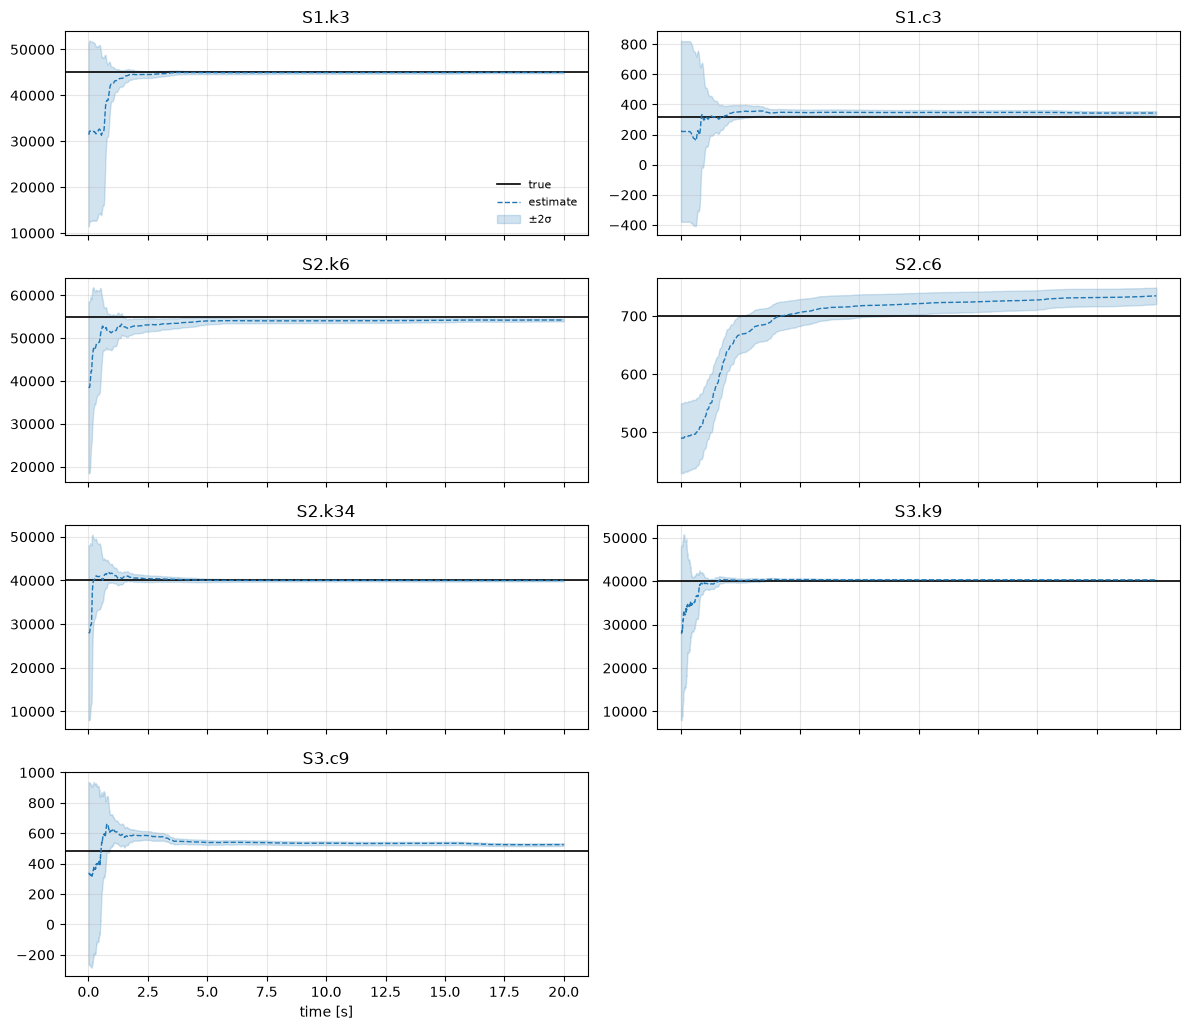

In [5]:
results.plot_parameters();

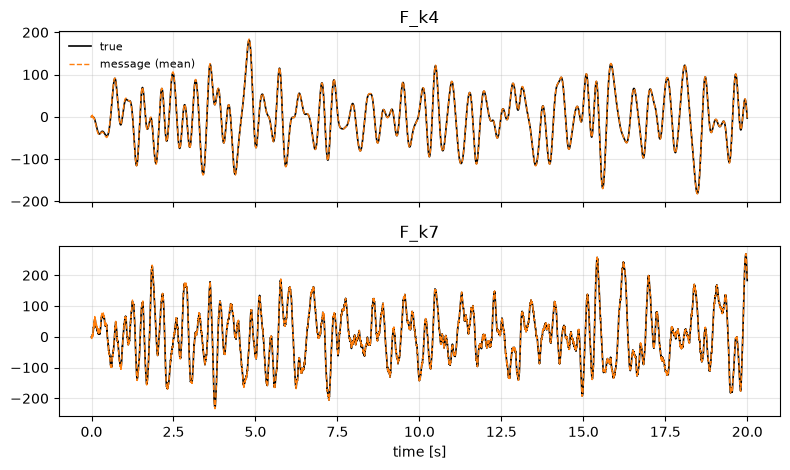

In [6]:
results.plot_messages();

Stiffnesses converge within a few seconds; dampings identified from accelerations
alone converge more slowly, as in the paper's 6-DOF study.

## The YAML twin

In [7]:
yaml_results = pci.solve("05_six_dof_three_subsystems.yaml")
print("YAML twin:", {p: round(yaml_results.final(p), 1) for p in ["k3", "c3", "k6", "c6", "k34", "k9", "c9"]})

YAML twin: {'k3': 45004.2, 'c3': 343.3, 'k6': 54224.2, 'c6': 734.6, 'k34': 39992.3, 'k9': 40299.8, 'c9': 525.7}
